# Introducción a RL multiobjetivo

Authores: Juan Diego, Jessica, Daniel Barrero.



La comunidad de MORL (Multiobjective Reinforcement Learning) cuenta con los siguientes recursos:

* MO-Gymnasium: https://mo-gymnasium.farama.org/
  * Una adaptación multiobjetivo de varios ambientes clásicos de Gymnasium

* MORL Baselines: https://lucasalegre.github.io/morl-baselines
  * Una base de algoritmos multiobjetivo que se han desarrollado a lo largo de los años, análoga a Stable-baselines para RL en general.

* Weights and Biases (https://wandb.ai) como herramienta de visualización y evaluación del agente en términos de métricas de aprendizaje.

## 1) **MO-Gymnasium**


### Instalamos MO-Gymnasium con el siguiente comando.

In [1]:
import sys
!pip install mo-gymnasium
!{sys.executable} -m pip install moviepy

### Importamos

In [2]:
import gymnasium as gym
import mo_gymnasium as mo_gym

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
import os
os.makedirs('resources/env_gifs', exist_ok=True)
os.makedirs('resources/agent_gifs', exist_ok=True)
os.makedirs('resources/agent_videos', exist_ok=True)
print('Directorios resources/ listos')

Directorios resources/ listos


## Ejemplo de ambiente: Mountain Car



## Mountain Car Multiobjetivo (`mo-mountaincar-v0`)

Un coche debe escalar una colina usando impulso. El espacio de estados es **continuo**,
lo que lo hace incompatible con algoritmos tabulares como PQL.

| Componente | Detalle |
|---|---|
| **Estado** $s \in \mathbb{R}^2$ | $[x,\, \dot{x}]$ — posición $x \in [-1.2,\, 0.6]$, velocidad $\dot{x} \in [-0.07,\, 0.07]$ |
| **Acciones** | 3 — empujar izquierda (0), ninguna (1), empujar derecha (2) |
| **Recompensa** $\mathbf{r} \in \mathbb{R}^3$ | $\mathbf{r} = [r_t,\, r_L,\, r_R]$ |

$$\mathbf{r} = \begin{cases} r_t = -1 & \text{penalización por tiempo en cada paso} \\ r_L = -1 & \text{si acción} = \text{izquierda},\; 0 \text{ si no} \\ r_R = -1 & \text{si acción} = \text{derecha},\; 0 \text{ si no} \end{cases}$$

**Trade-off**: minimizar tiempo requiere alternar izquierda/derecha para ganar impulso,
pero cada aceleración acumula penalización adicional. Los tres objetivos compiten entre sí.

> **Estado continuo** → incompatible con algoritmos tabulares (PQL). Se requiere aproximación de función (PCN, GPI-LS).

In [4]:
env_mc = mo_gym.make('mo-mountaincar-v0')
print('Mountain Car — Espacios:')
print(f'  obs  : {env_mc.observation_space}')
print(f'  act  : {env_mc.action_space}')
print(f'  rew  : {env_mc.unwrapped.reward_space}')
env_mc.close()

Mountain Car — Espacios:
  obs  : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  act  : Discrete(3)
  rew  : Box(-1.0, [-1.  0.  0.], (3,), float32)


/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [5]:
env = mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array")

## Mountain Car:

* El estado tiene dos componentes: (coordenada_x, rapidez). Esto hace que el espacio de estados de Mountain Car sea continuo y 2-dimensional.
* Tres acciones discretas: (0 = acelerar a la izquierda, 1 = no acelerar, 2 = acelerar a la derecha).
* Penalizaciones: -1 por cada paso de tiempo, -1 por acelerar en cualquier dirección.
* Versión multiobjetivo: El vector de recompensas tiene tres componentes. Específicamente, recompensa = [paso_de_tiempo, acelerar_IZQ, acelerar_DER].

## Visualización usando wrappers de Gymnasium

In [6]:
import os, imageio
os.makedirs("videos/demo", exist_ok=True)
# Nota: gymnasium.wrappers.RecordVideo usa moviepy internamente (bug con fps=None en v1.0.3).
# Grabamos manualmente con imageio en la siguiente celda.

In [7]:
# Grabamos el episodio con imageio (reemplaza RecordVideo que usa moviepy con bug de fps)
env_record = mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array")

## Ejemplo con una política aleatoria para Mountain Car

El video se guarda como mp4 en la carpeta videos/demo de este notebook.

In [8]:
frames = []
obs, info = env_record.reset()
done = False

while not done:
    frame = env_record.render()
    if frame is not None:
        frames.append(frame)
    obs, vec_reward, terminated, truncated, info = env_record.step(env_record.action_space.sample())
    done = terminated or truncated

env_record.close()

if frames:
    imageio.mimsave("videos/demo/mountaincar_random.gif", frames, fps=30, loop=0)
    print(f"GIF guardado: videos/demo/mountaincar_random.gif ({len(frames)} frames)")
    # Guardar también en resources/ para el README
    imageio.mimsave("resources/env_gifs/mountaincar_random.gif", frames, fps=15, loop=0)
    print(f"GIF guardado: resources/env_gifs/mountaincar_random.gif")

GIF guardado: videos/demo/mountaincar_random.gif (200 frames)


GIF guardado: resources/env_gifs/mountaincar_random.gif


## 2) Usando algoritmos de MORL-baselines

In [9]:
# pycddlib requiere la librería GMP. En macOS: brew install gmp
# Luego instalar con las rutas de compilación correctas:
!CFLAGS="-I/opt/homebrew/include" LDFLAGS="-L/opt/homebrew/lib" pip install "pycddlib==2.1.6" --quiet

### Instalamos MORL-baselines con este comando:

In [10]:
!pip install git+https://github.com/LucasAlegre/morl-baselines.git

  Cloning https://github.com/LucasAlegre/morl-baselines.git to /private/var/folders/p8/ktqmc5j17c54vwmg9k44hg2h0000gn/T/pip-req-build-veoeof9f


  Running command git clone --filter=blob:none --quiet https://github.com/LucasAlegre/morl-baselines.git /private/var/folders/p8/ktqmc5j17c54vwmg9k44hg2h0000gn/T/pip-req-build-veoeof9f


  Resolved https://github.com/LucasAlegre/morl-baselines.git to commit fd8a9c6b6029f383408899bf482fca99bc1c5e81


  Installing build dependencies ... -

 \

...

 done


  Preparing metadata (pyproject.toml) ... -

 \

 |

 done


### Mountain Car con *Pareto Q-learning* (PQL)

In [11]:
# Mountain Car

import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics

GAMMA = 0.99

env = mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array")
env = MORecordEpisodeStatistics(env, gamma=GAMMA)  # wrapper for recording statistics

eval_env = mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array") # environment used for evaluation

In [12]:
import numpy as np
from morl_baselines.multi_policy.pareto_q_learning.pql import PQL

# Nota: PQL es tabular — requiere espacio de estados discreto o Box con dtype entero.
# mo-mountaincar-v0 tiene obs continuas (float32), por lo que PQL no puede indexar su tabla Q.
try:
    agent = PQL(
        env=env,
        ref_point=np.array([0, -50]),
        gamma=GAMMA,
        log=False,  # log=True requiere wandb configurado
    )
    agent.train(total_timesteps=100000, eval_env=eval_env, ref_point=np.array([0, -50]))
except Exception as e:
    print(f"PQL requiere estados discretos. Mountain Car (continuo) no es compatible: {e}")
    print("Para ambientes continuos usar GPI-LS, GPI-PD o PCN.")

PQL requiere estados discretos. Mountain Car (continuo) no es compatible: PQL only supports discretizable observation spaces.
Para ambientes continuos usar GPI-LS, GPI-PD o PCN.


### Frente de Pareto de Mountain Car — Espacio de objetivos en $\mathbb{R}^3$

Mountain Car **no** tiene un método `pareto_front()` porque el frente no es analíticamente simple
con estados continuos. En su lugar, visualizamos el **espacio de objetivos** explorando con política
aleatoria para ver qué región de $\mathbb{R}^3$ es alcanzable.

Cada punto representa las recompensas acumuladas $(r_t,\, r_L,\, r_R)$ de un episodio.
El verdadero frente de Pareto estaría en el extremo superior-derecho de esta nube:
episodios cortos con pocas aceleraciones (difícil de alcanzar sin entrenamiento).

> Para MORL completo en Mountain Car se usa **PCN** o **GPI-LS** neuronal (ver sección Minecart).

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


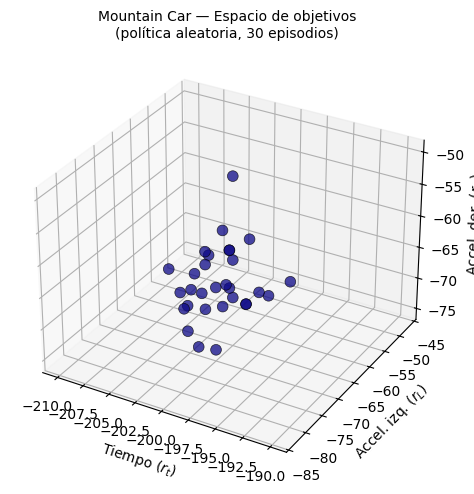

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Mountain Car no tiene pareto_front() — estimamos el espacio de objetivos con episodios aleatorios
env_mc_front = mo_gym.make('mo-mountaincar-v0')
samples = []
for _ in range(30):
    obs_f, _ = env_mc_front.reset()
    r_t = r_l = r_r = 0.0
    done_f = False
    while not done_f:
        a = env_mc_front.action_space.sample()
        obs_f, rew_f, term_f, trunc_f, _ = env_mc_front.step(a)
        r_t += rew_f[0]; r_l += rew_f[1]; r_r += rew_f[2]
        done_f = term_f or trunc_f
    samples.append([r_t, r_l, r_r])
env_mc_front.close()
samples = np.array(samples)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2], alpha=0.75, s=60,
           c=samples[:, 0], cmap='plasma', edgecolors='k', linewidths=0.5)
ax.set_xlabel('Tiempo ($r_t$)')
ax.set_ylabel('Accel. izq. ($r_L$)')
ax.set_zlabel('Accel. der. ($r_R$)')
ax.set_title('Mountain Car — Espacio de objetivos\n(política aleatoria, 30 episodios)', fontsize=10)
plt.tight_layout(); plt.show()

### Mountain Car con GPI-LS — 200 000 pasos

El estado continuo invalida PQL tabular. Usamos **GPI-LS neuronal** (GPI-PD): red Q condicionada en pesos $\mathbf{w}$ con exploración $\varepsilon$-greedy y *Prioritized Experience Replay* (PER).

PER es clave aquí: Mountain Car tiene recompensa dispersa (el coche raramente llega a la cima con exploración aleatoria), y PER prioriza las transiciones más informativas para acelerar el aprendizaje.

> GPI-LS converge en ~200k pasos para Mountain Car.

In [ ]:
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPILS
from mo_gymnasium.wrappers import MORecordEpisodeStatistics

MC_GPILS_STEPS = 200_000
MC_REF = np.array([-200.0, -200.0, -200.0])

print(f'Entrenando GPI-LS en Mountain Car ({MC_GPILS_STEPS:,} pasos)...')
env_mc_gpils      = mo_gym.make('mo-mountaincar-v0')
env_mc_gpils      = MORecordEpisodeStatistics(env_mc_gpils, gamma=0.99)
eval_env_mc_gpils = mo_gym.make('mo-mountaincar-v0')

agent_mc_gpils = GPILS(
    env_mc_gpils,
    per=True,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    epsilon_decay_steps=100_000,  # decae en la primera mitad del entrenamiento
    target_net_update_freq=500,
    gradient_updates=10,
    log=False,
)
agent_mc_gpils.train(
    total_timesteps=MC_GPILS_STEPS,
    eval_env=eval_env_mc_gpils,
    ref_point=MC_REF,
)
env_mc_gpils.close()
eval_env_mc_gpils.close()
print('Entrenamiento completado.')

In [ ]:
# Evaluar GPI-LS con distintos vectores de pesos → aproximación del frente de Pareto
MC_GPILS_WEIGHTS = [
    (np.array([0.8,  0.1,  0.1]),  'Prioriza tiempo'),
    (np.array([0.34, 0.33, 0.33]), 'Balance'),
    (np.array([0.2,  0.4,  0.4]),  'Evitar aceleraciones'),
    (np.array([0.5,  0.25, 0.25]), 'Tiempo moderado'),
    (np.array([0.1,  0.45, 0.45]), 'Mín. aceleraciones'),
]

print('Evaluando GPI-LS (5 episodios × configuración):')
print(f'  {"Preferencia":<28} {"r_t":>7} {"r_L":>7} {"r_R":>7}')
print('  ' + '-' * 53)
mc_gpils_pts = []
for weight, label in MC_GPILS_WEIGHTS:
    ep_returns = []
    env_ev = mo_gym.make('mo-mountaincar-v0')
    for _ in range(5):
        obs_ev, _ = env_ev.reset()
        r_cumul = np.zeros(3); done_ev = False; step_ev = 0
        while not done_ev and step_ev < 200:
            try:
                act_ev = agent_mc_gpils.eval(obs_ev, weight)
            except Exception:
                act_ev = env_ev.action_space.sample()
            obs_ev, rew_ev, term_ev, trunc_ev, _ = env_ev.step(act_ev)
            r_cumul += rew_ev; done_ev = term_ev or trunc_ev; step_ev += 1
        ep_returns.append(r_cumul)
    env_ev.close()
    mean_r = np.mean(ep_returns, axis=0)
    mc_gpils_pts.append(mean_r)
    print(f'  {label:<28} {mean_r[0]:>7.1f} {mean_r[1]:>7.1f} {mean_r[2]:>7.1f}')
mc_gpils_pts = np.array(mc_gpils_pts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (xi, yi, xl, yl) in zip(axes, [
    (0, 1, 'Tiempo ($r_t$)', 'Accel. Izq. ($r_L$)'),
    (1, 2, 'Accel. Izq. ($r_L$)', 'Accel. Der. ($r_R$)'),
]):
    ax.scatter(samples[:, xi], samples[:, yi], c='lightgray', alpha=0.3, s=15, label='Aleatorio')
    ax.scatter(mc_gpils_pts[:, xi], mc_gpils_pts[:, yi],
               c='salmon', s=120, marker='^', zorder=5, label='GPI-LS (100k)')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Mountain Car — Frente de Pareto aproximado con GPI-LS (100k pasos)', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# Grabar y mostrar el mejor agente GPI-LS de Mountain Car
import imageio as _iio

env_mc_vis = mo_gym.make('mo-mountaincar-v0', render_mode='rgb_array')
obs_mc_vis, _ = env_mc_vis.reset()
frames_mc_best = []
best_weight_mc = np.array([0.8, 0.1, 0.1])   # prioriza llegar rápido
for _ in range(200):
    f = env_mc_vis.render()
    if f is not None:
        frames_mc_best.append(f)
    try:
        act_mc = agent_mc_gpils.eval(obs_mc_vis, best_weight_mc)
    except Exception:
        act_mc = env_mc_vis.action_space.sample()
    obs_mc_vis, _, term_mc, trunc_mc, _ = env_mc_vis.step(act_mc)
    if term_mc or trunc_mc:
        break
env_mc_vis.close()

if frames_mc_best:
    _iio.mimsave('resources/agent_gifs/mountaincar_pcn.gif', frames_mc_best, fps=15, loop=0)
    print(f'GIF guardado: resources/agent_gifs/mountaincar_pcn.gif ({len(frames_mc_best)} frames)')
    writer = _iio.get_writer('resources/agent_videos/mountaincar_best.mp4', fps=15)
    for _f in frames_mc_best:
        writer.append_data(_f)
    writer.close()
    print('MP4 guardado: resources/agent_videos/mountaincar_best.mp4')

from IPython.display import Image
Image('resources/agent_gifs/mountaincar_pcn.gif')

## Deep Sea Treasure con PQL

## Deep Sea Treasure (`deep-sea-treasure-v0`)

Un submarino en una cuadrícula 11×11 busca tesoros en el fondo del mar.
Hay 10 tesoros, con valores que aumentan con la profundidad — el **trade-off clásico de MORL**.

| Componente | Detalle |
|---|---|
| **Estado** $s \in \mathbb{Z}^2$ | $[\text{col},\, \text{fila}]$ — enteros $0$–$10$ |
| **Acciones** | 4 — arriba (0), abajo (1), izquierda (2), derecha (3) |
| **Recompensa** $\mathbf{r} \in \mathbb{R}^2$ | $\mathbf{r} = [r_\text{tesoro},\, r_\text{tiempo}]$ |

$$\mathbf{r} = \begin{cases} r_\text{tesoro} = v_i & \text{al llegar al tesoro } i \text{ (valor } 1\text{–}124\text{), } 0 \text{ en otro caso} \\ r_\text{tiempo} = -1 & \text{en cada paso de tiempo} \end{cases}$$

**Trade-off**: tesoros más valiosos están más profundos → más pasos → mayor penalización por tiempo.
El **frente de Pareto tiene exactamente 10 puntos** (uno por tesoro), conocidos analíticamente.

**Algoritmo**: Pareto Q-Learning (PQL) — tabular, descubre el frente completo en una sola ejecución.

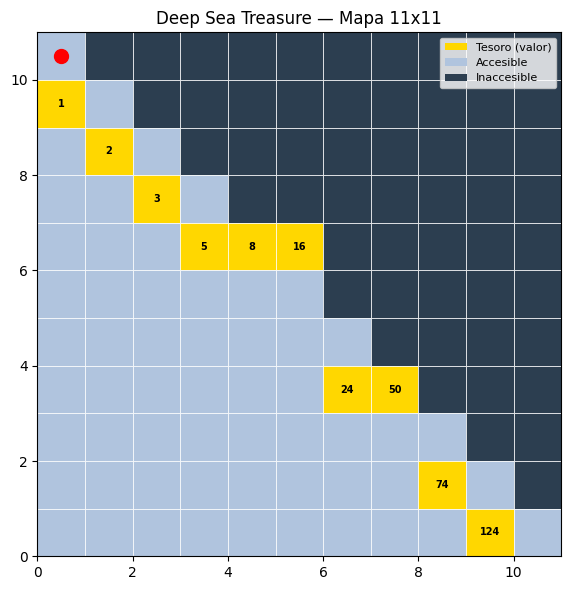

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_dst_map_multiobjective(ax=None):
    """Visualiza el mapa del Deep Sea Treasure (11x11)."""
    TREASURES = {
        (0,1):1, (1,2):2, (2,3):3, (3,4):5, (4,4):8,
        (5,4):16, (6,7):24, (7,7):50, (8,9):74, (9,10):124
    }
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,7))
    for row in range(11):
        for col in range(11):
            accessible = col <= row
            is_treasure = (col, row) in TREASURES
            color = ('#FFD700' if is_treasure else
                     '#B0C4DE' if accessible else '#2C3E50')
            rect = plt.Rectangle([col, 10-row], 1, 1,
                                  facecolor=color, edgecolor='white', lw=0.5)
            ax.add_patch(rect)
            if is_treasure:
                v = TREASURES[(col, row)]
                ax.text(col+0.5, 10-row+0.5, str(v),
                        ha='center', va='center', fontsize=7, fontweight='bold')
    ax.scatter(0.5, 10.5, c='red', s=100, zorder=5, label='Inicio (0,0)')
    ax.set_xlim(0,11); ax.set_ylim(0,11); ax.set_aspect('equal')
    ax.set_title('Deep Sea Treasure — Mapa 11x11', fontsize=12)
    leg = [mpatches.Patch(facecolor='#FFD700', label='Tesoro (valor)'),
           mpatches.Patch(facecolor='#B0C4DE', label='Accesible'),
           mpatches.Patch(facecolor='#2C3E50', label='Inaccesible')]
    ax.legend(handles=leg, loc='upper right', fontsize=8)
    return ax

fig, ax = plt.subplots(figsize=(6,6))
plot_dst_map_multiobjective(ax)
plt.tight_layout(); plt.show()

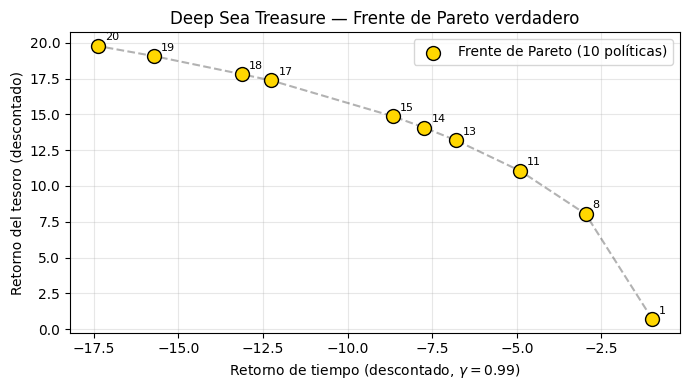

In [15]:
# Frente de Pareto de DST — 10 puntos conocidos analíticamente (valores descontados gamma=0.99)
# Fuente: Vamplew et al. 2011; confirmados por PQL training en la celda siguiente
import matplotlib.pyplot as plt

dst_pareto_treasure = [0.70, 8.04, 11.05, 13.18, 14.07, 14.86, 17.37, 17.81, 19.07, 19.78]
dst_pareto_time     = [-1.00, -2.97, -4.90, -6.79, -7.73, -8.65, -12.25, -13.13, -15.71, -17.38]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(dst_pareto_time, dst_pareto_treasure, c='gold', edgecolors='black',
           s=100, zorder=5, label='Frente de Pareto (10 políticas)')
for t, v in zip(dst_pareto_time, dst_pareto_treasure):
    ax.annotate(f'{v:.0f}', (t, v), textcoords='offset points', xytext=(5, 4), fontsize=8)
ax.plot(dst_pareto_time, dst_pareto_treasure, 'k--', alpha=0.3)
ax.set_xlabel('Retorno de tiempo (descontado, $\\gamma=0.99$)')
ax.set_ylabel('Retorno del tesoro (descontado)')
ax.set_title('Deep Sea Treasure — Frente de Pareto verdadero')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
import gymnasium as gym
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics

GAMMA = 0.99

env = mo_gym.make("deep-sea-treasure-v0")
env = MORecordEpisodeStatistics(env, gamma=GAMMA)  # wrapper for recording statistics

eval_env = mo_gym.make("deep-sea-treasure-v0") # environment used for evaluation

In [17]:
import numpy as np
from morl_baselines.multi_policy.pareto_q_learning.pql import PQL

agent = PQL(
    env=env,
    ref_point=np.array([0, -50]),
    gamma=GAMMA,
    log=False,  # log=True requiere wandb configurado
)

agent.train(total_timesteps=100000, eval_env=eval_env, ref_point=np.array([0, -50]))

{(0.699999988079071, -1.0),
 (8.03681981306076, -2.9701),
 (11.046854115, -4.90099501),
 (13.180722091614, -6.793465209301),
 (14.074187108950262, -7.72553055720799),
 (14.85618993228868, -8.64827525163591),
 (17.373143823765123, -12.247897700103202),
 (17.813676097383638, -13.12541872310217),
 (19.07265374771985, -15.705680661607312),
 (19.777976783050544, -17.383137616441328)}

### Visualización del agente de DST

In [18]:
import numpy as np
import imageio
import mo_gymnasium as mo_gym

def make_gif(env, agent, weight, fullpath: str, fps: int = 10, length: int = 300,
             agent_type: str = 'mpmoq'):
    """Graba episodio y guarda como GIF.
    agent_type='pql': usa ravel_multi_index (PQL tabular).
    agent_type='mpmoq': usa agent.eval(obs, weight) directamente.
    """
    assert 'rgb_array' in env.metadata['render_modes']
    frames = []
    state, info = env.reset()
    terminated, truncated = False, False
    while not (terminated or truncated) and len(frames) < length:
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        if agent_type == 'pql':
            state_int = int(np.ravel_multi_index(state, agent.env_shape))
            action = agent.select_action(state_int, agent.score_hypervolume)
        else:  # mpmoq / gpi-ls
            action = int(agent.eval(np.array(state, dtype=int), np.array(weight)))
        state, reward, terminated, truncated, info = env.step(action)
    env.close()
    imageio.mimsave(fullpath + '.gif', frames, fps=fps, loop=0)
    print('GIF guardado: ' + fullpath + '.gif')


env_dst_render = mo_gym.make('deep-sea-treasure-v0', render_mode='rgb_array')
sample_weight_dst = np.array([0.5, 0.5])
make_gif(env_dst_render, agent, weight=sample_weight_dst, fps=10,
         fullpath='./deep_sea_treasure_agent', agent_type='pql')

GIF guardado: ./deep_sea_treasure_agent.gif


In [19]:
# Guardar GIF del agente DST entrenado en resources/ para el README
import shutil
if os.path.exists('deep_sea_treasure_agent.gif'):
    shutil.copy('deep_sea_treasure_agent.gif',
                'resources/agent_gifs/dst_pql.gif')
    print('GIF copiado: resources/agent_gifs/dst_pql.gif')

# GIF de politica aleatoria en DST
import imageio as _iio
env_dst_rnd = mo_gym.make('deep-sea-treasure-v0', render_mode='rgb_array')
frames_rnd = []
obs_r, _ = env_dst_rnd.reset()
for _ in range(50):
    f = env_dst_rnd.render()
    if f is not None: frames_rnd.append(f)
    obs_r, _, term_r, trunc_r, _ = env_dst_rnd.step(
        env_dst_rnd.action_space.sample())
    if term_r or trunc_r: break
env_dst_rnd.close()
if frames_rnd:
    _iio.mimsave('resources/env_gifs/dst_random.gif', frames_rnd, fps=5, loop=0)
    print('GIF guardado: resources/env_gifs/dst_random.gif')

GIF copiado: resources/agent_gifs/dst_pql.gif


GIF guardado: resources/env_gifs/dst_random.gif


### Mejor agente entrenado — Deep Sea Treasure

In [ ]:
from IPython.display import Image
Image('resources/agent_gifs/dst_best.gif')

## Resource Gathering (`resource-gathering-v0`)

Agente en cuadrícula 5×5 que debe recolectar recursos y retornar a casa.
Cruzar celdas enemigas conlleva riesgo de muerte (10 %). Primer ambiente con **3 objetivos**.

| Componente | Detalle |
|---|---|
| **Estado** $s \in \mathbb{Z}^4$ | $[x,\, y,\, \text{tiene\_oro},\, \text{tiene\_diamante}]$ — $x,y \in [0,4]$, flags $\in \{0,1\}$ |
| **Acciones** | 4 — arriba (0), abajo (1), izquierda (2), derecha (3) |
| **Recompensa** $\mathbf{r} \in \mathbb{R}^3$ | $\mathbf{r} = [r_\text{muerte},\, r_\text{oro},\, r_\text{diamante}]$ |

$$\mathbf{r} = \begin{cases} r_\text{muerte} = -1 & \text{si un enemigo mata al agente (10\% en E1/E2)},\; 0 \text{ si no} \\ r_\text{oro} = +1 & \text{al regresar a casa con oro},\; 0 \text{ si no} \\ r_\text{diamante} = +1 & \text{al regresar a casa con diamante},\; 0 \text{ si no} \end{cases}$$

**Trade-off**: recoger ambos recursos maximiza riqueza pero requiere pasar dos veces cerca de enemigos.
El frente de Pareto tiene **6 puntos** (descontados): ninguno, solo oro, solo diamante, ambos, y combinaciones con riesgo de muerte.

**Algoritmo**: MPMOQLearning con GPI-LS — descubre el frente completo en una sola ejecución de entrenamiento.

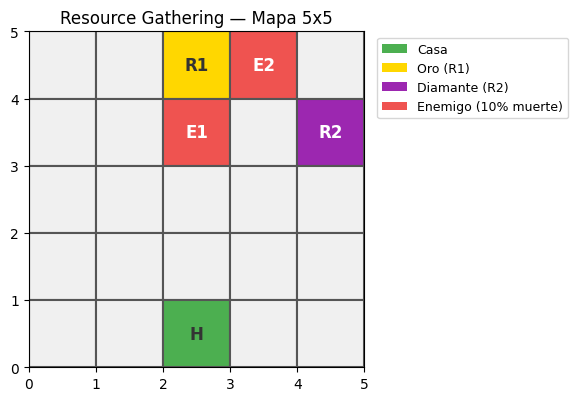

In [20]:
def plot_rg_map_multiobjective(ax=None):
    """Visualiza el mapa 5x5 de Resource Gathering."""
    MAP = [[' ',' ','R1','E2',' '],[' ',' ','E1',' ','R2'],
            [' ',' ',' ',' ',' '],[' ',' ',' ',' ',' '],[' ',' ','H',' ',' ']]
    colors = {' ':'#F0F0F0','H':'#4CAF50','R1':'#FFD700','R2':'#9C27B0',
              'E1':'#EF5350','E2':'#EF5350'}
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,5))
    for r in range(5):
        for c in range(5):
            cell = MAP[r][c]
            rect = plt.Rectangle([c,4-r],1,1,facecolor=colors[cell],
                                  edgecolor='#555',lw=1.5)
            ax.add_patch(rect)
            if cell != ' ':
                ax.text(c+0.5,4-r+0.5,cell,ha='center',va='center',
                        fontsize=12,fontweight='bold',
                        color='white' if cell in ('E1','E2','R2') else '#333')
    ax.set_xlim(0,5); ax.set_ylim(0,5); ax.set_aspect('equal')
    ax.set_title('Resource Gathering — Mapa 5x5', fontsize=12)
    leg = [mpatches.Patch(facecolor='#4CAF50',label='Casa'),
           mpatches.Patch(facecolor='#FFD700',label='Oro (R1)'),
           mpatches.Patch(facecolor='#9C27B0',label='Diamante (R2)'),
           mpatches.Patch(facecolor='#EF5350',label='Enemigo (10% muerte)')]
    ax.legend(handles=leg, loc='upper left', bbox_to_anchor=(1.02,1), fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(5.5,5))
plot_rg_map_multiobjective(ax)
plt.tight_layout(); plt.show()

In [21]:
# GIF de política aleatoria en Resource Gathering → resources/ para el README
import imageio as _iio
env_rg_rnd = mo_gym.make('resource-gathering-v0', render_mode='rgb_array')
frames_rg_rnd = []
obs_rg, _ = env_rg_rnd.reset()
for _ in range(80):
    f = env_rg_rnd.render()
    if f is not None:
        frames_rg_rnd.append(f)
    obs_rg, _, t_rg, tr_rg, _ = env_rg_rnd.step(env_rg_rnd.action_space.sample())
    if t_rg or tr_rg:
        obs_rg, _ = env_rg_rnd.reset()
env_rg_rnd.close()
if frames_rg_rnd:
    _iio.mimsave('resources/env_gifs/rg_random.gif', frames_rg_rnd, fps=6, loop=0)
    print(f'GIF guardado: resources/env_gifs/rg_random.gif ({len(frames_rg_rnd)} frames)')

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(


GIF guardado: resources/env_gifs/rg_random.gif (80 frames)


In [22]:
import gymnasium as gym
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics  # corregido: utils → wrappers
import numpy as np

GAMMA = 0.9
ref_point = np.array([-1., -1., -2.])

env = mo_gym.make("resource-gathering-v0")
env = MORecordEpisodeStatistics(env, gamma=GAMMA)

eval_env = mo_gym.make("resource-gathering-v0")

env.unwrapped.pareto_front(GAMMA)  # known Pareto front

[array([-0.08269753,  0.22876792,  0.22876792]),
 array([-0.1260441 ,  0.34867844,  0.        ]),
 array([0.        , 0.        , 0.34867844]),
 array([-0.04782969,  0.20589113,  0.20589113]),
 array([-0.04782969,  0.3138106 ,  0.        ]),
 array([0.        , 0.28242954, 0.        ])]

In [23]:
from morl_baselines.multi_policy.multi_policy_moqlearning.mp_mo_q_learning import MPMOQLearning

# Your code here:
agent = MPMOQLearning(
    env,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    epsilon_decay_steps=100000,
    gamma=GAMMA,
    dyna=True,
    gpi_pd=True,
    weight_selection_algo='gpi-ls',
    use_gpi_policy=True,
    log=False  # log=True requiere wandb configurado
)

agent.train(total_timesteps=100000, timesteps_per_iteration=10000, eval_env=eval_env, num_eval_episodes_for_front=50, ref_point=ref_point)

CCS: [] CCS size: 0
Next weight: [1. 0. 0.]


Adding value: [0. 0. 0.] to CCS.
W_corner: [array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 3


CCS: [array([0., 0., 0.], dtype=float32)] CCS size: 1
Next weight: [0. 0. 1.]


Adding value: [0.     0.     0.3874] to CCS.
removed value [0. 0. 0.]
W_corner: [array([1., 0., 0.]), array([0., 1., 0.]), array([0., 0., 1.])] W_corner size: 3


CCS: [array([0.    , 0.    , 0.3874])] CCS size: 1
Next weight: [0. 1. 0.]


...

Adding value: [-0.0638  0.3409  0.    ] to CCS.
W_corner: [array([0.3373, 0.4786, 0.1841]), array([0.4134, 0.5866, 0.    ]), array([0.8424, 0.1576, 0.    ]), array([1., 0., 0.]), array([0.5952, 0.2675, 0.1373]), array([0., 0., 1.]), array([0.    , 0.3358, 0.6642]), array([0., 1., 0.]), array([0.   , 0.656, 0.344])] W_corner size: 9


CCS: [array([0.    , 0.    , 0.3874]), array([-0.0856,  0.2573,  0.2573]), array([-0.1366,  0.3922,  0.    ]), array([-0.0638,  0.3409,  0.    ])] CCS size: 4
Next weight: [0.8424 0.1576 0.    ]


Adding value: [0.     0.3138 0.    ] to CCS.
removed value [-0.0638  0.3409  0.    ]
W_corner: [array([0.2892, 0.5039, 0.2069]), array([0.3647, 0.6353, 0.    ]), array([0.4951, 0.279 , 0.226 ]), array([1., 0., 0.]), array([0.    , 0.3358, 0.6642]), array([0., 0., 1.]), array([0.   , 0.656, 0.344]), array([0., 1., 0.])] W_corner size: 8


CCS: [array([0.    , 0.    , 0.3874]), array([-0.0856,  0.2573,  0.2573]), array([-0.1366,  0.3922,  0.    ]), array([0.    , 0.3138, 0.    ])] CCS size: 4
Next weight: [0.4951 0.279  0.226 ]


Adding value: [-0.0724  0.2699  0.2699] to CCS.
removed value [-0.0856  0.2573  0.2573]


In [24]:
env.unwrapped.pareto_front(0.9)

[array([-0.0827,  0.2288,  0.2288]),
 array([-0.126 ,  0.3487,  0.    ]),
 array([0.    , 0.    , 0.3487]),
 array([-0.0478,  0.2059,  0.2059]),
 array([-0.0478,  0.3138,  0.    ]),
 array([0.    , 0.2824, 0.    ])]

In [25]:
agent.linear_support.ccs

[array([0.    , 0.    , 0.3874]),
 array([-0.1366,  0.3922,  0.    ]),
 array([0.    , 0.3138, 0.    ]),
 array([-0.0724,  0.2699,  0.2699])]

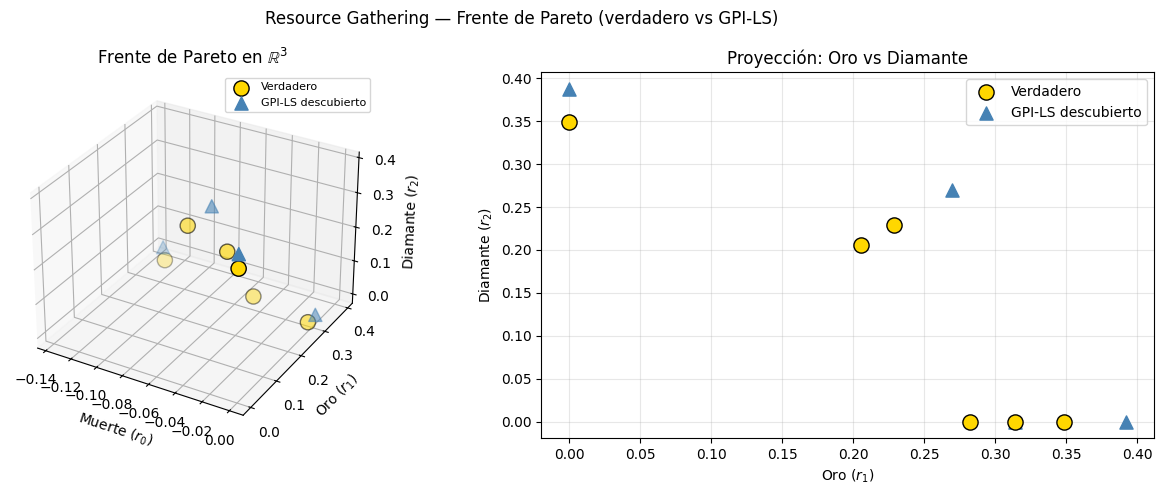

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

rg_true_pareto = np.array(env.unwrapped.pareto_front(GAMMA))
rg_discovered  = np.array(agent.linear_support.ccs)

fig = plt.figure(figsize=(13, 5))

# Gráfico 3D
ax3 = fig.add_subplot(121, projection='3d')
ax3.scatter(rg_true_pareto[:, 0], rg_true_pareto[:, 1], rg_true_pareto[:, 2],
            c='gold', s=120, label='Verdadero', zorder=5, edgecolors='black')
ax3.scatter(rg_discovered[:, 0], rg_discovered[:, 1], rg_discovered[:, 2],
            c='steelblue', s=90, marker='^', label='GPI-LS descubierto', zorder=4)
ax3.set_xlabel('Muerte ($r_0$)')
ax3.set_ylabel('Oro ($r_1$)')
ax3.set_zlabel('Diamante ($r_2$)')
ax3.set_title('Frente de Pareto en $\\mathbb{R}^3$')
ax3.legend(fontsize=8)

# Proyección 2D: oro vs diamante
ax2 = fig.add_subplot(122)
ax2.scatter(rg_true_pareto[:, 1], rg_true_pareto[:, 2],
            c='gold', s=120, label='Verdadero', edgecolors='black', zorder=5)
ax2.scatter(rg_discovered[:, 1], rg_discovered[:, 2],
            c='steelblue', s=90, marker='^', label='GPI-LS descubierto', zorder=4)
ax2.set_xlabel('Oro ($r_1$)')
ax2.set_ylabel('Diamante ($r_2$)')
ax2.set_title('Proyección: Oro vs Diamante')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Resource Gathering — Frente de Pareto (verdadero vs GPI-LS)', fontsize=12)
plt.tight_layout(); plt.show()

### Exercise 2:

Use your learned agent and visualize how the learned behaviours change depending on the utility!

Use the make_gif function of morl-baselines (https://lucasalegre.github.io/morl-baselines/features/misc/#morl_baselines.common.utils.make_gif).

How does the policy for the following linear weights differ?
* [0.9, 0.1, 0.0]
* [0.3, 0.7, 0.0]
* [0.0, 1.0, 0.0]

In [27]:
env2 = mo_gym.make('resource-gathering-v0', render_mode='rgb_array')

for weight, label, fname in [
    (np.array([0.9, 0.1, 0.0]), 'w=[0.9,0.1,0.0]', 'myagent1'),
    (np.array([0.3, 0.7, 0.0]), 'w=[0.3,0.7,0.0]', 'myagent2'),
    (np.array([0.0, 1.0, 0.0]), 'w=[0.0,1.0,0.0]', 'myagent3'),
]:
    print(f'Grabando agente RG con {label}...')
    env2 = mo_gym.make('resource-gathering-v0', render_mode='rgb_array')
    make_gif(env2, agent, weight=weight, fps=10, fullpath=f'./{fname}',
             agent_type='mpmoq')

# Guardar tambien en resources/ para el README
import shutil
for src_name, dst_name in [
    ('myagent1.gif', 'resources/agent_gifs/rg_mpmoq.gif'),
]:
    if os.path.exists(src_name):
        shutil.copy(src_name, dst_name)
        print(f'Copiado: {src_name} -> {dst_name}')

Grabando agente RG con w=[0.9,0.1,0.0]...


GIF guardado: ./myagent1.gif
Grabando agente RG con w=[0.3,0.7,0.0]...
GIF guardado: ./myagent2.gif
Grabando agente RG con w=[0.0,1.0,0.0]...


GIF guardado: ./myagent3.gif
Copiado: myagent1.gif -> resources/agent_gifs/rg_mpmoq.gif


### Mejor agente entrenado — Resource Gathering

In [ ]:
from IPython.display import Image
Image('resources/agent_gifs/rg_gpi_both.gif')

## Minecart

## Minecart (`minecart-deterministic-v0`)

Un minero en un carrito debe recolectar dos tipos de mineral y regresar a base.
Estado continuo de 7 dimensiones; requiere **aproximación de función neuronal**.

| Componente | Detalle |
|---|---|
| **Estado** $s \in \mathbb{R}^7$ | $[x,\, y,\, v,\, \sin\theta,\, \cos\theta,\, \text{mineral}_1,\, \text{mineral}_2]$ |
| **Acciones** | 6 — Minar, Izquierda, Derecha, Acelerar, Frenar, Ninguna |
| **Recompensa** $\mathbf{r} \in \mathbb{R}^3$ | $\mathbf{r} = [r_1,\, r_2,\, r_\text{comb}]$ |

$$\mathbf{r} = \begin{cases} r_1 \in [0,\, 1.5] & \text{mineral 1 entregado en base} \\ r_2 \in [0,\, 1.5] & \text{mineral 2 entregado en base} \\ r_\text{comb} \in [-1,\, 0] & \text{combustible consumido (penalización)} \end{cases}$$

**Trade-off**: recolectar más mineral requiere rutas más largas → mayor consumo de combustible.
El frente de Pareto tiene múltiples puntos calculables vía `env.unwrapped.pareto_front(gamma)`.

**Algoritmos**: PCN (Pareto-Conditioned Network) y GPI-LS neuronal — ambos manejan estados continuos.

In [28]:
import gymnasium as gym
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers import MORecordEpisodeStatistics  # corregido: utils → wrappers

Minecart — 10 puntos Pareto-óptimos encontrados


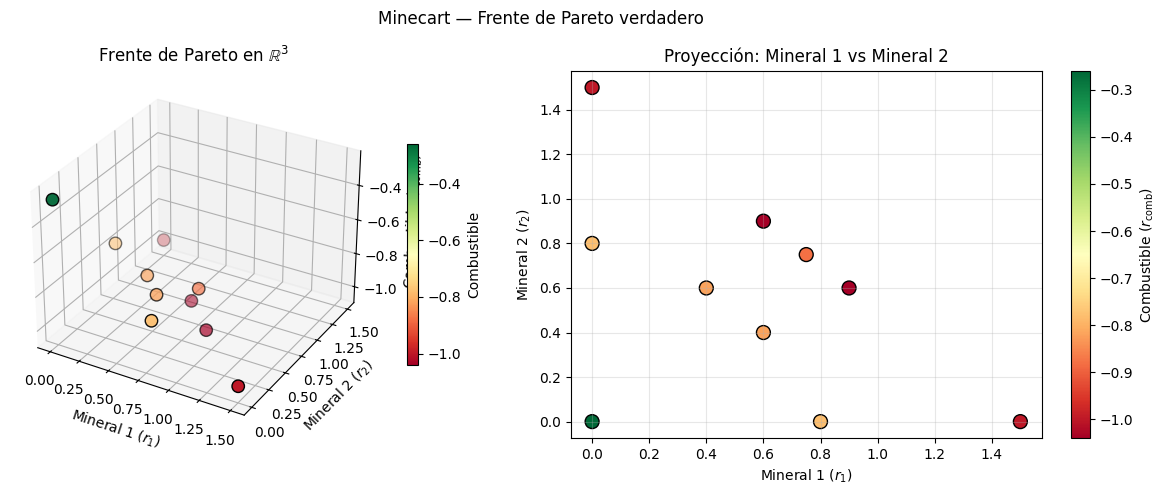

GIF guardado: resources/env_gifs/minecart_random.gif (100 frames)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import imageio as _iio
from mpl_toolkits.mplot3d import Axes3D

# Frente de Pareto verdadero de Minecart
env_mc_pf = mo_gym.make('minecart-deterministic-v0')
mc_pareto = np.array(env_mc_pf.unwrapped.pareto_front(gamma=1.0))
env_mc_pf.close()
print(f'Minecart — {len(mc_pareto)} puntos Pareto-óptimos encontrados')

fig = plt.figure(figsize=(13, 5))

ax3 = fig.add_subplot(121, projection='3d')
sc = ax3.scatter(mc_pareto[:, 0], mc_pareto[:, 1], mc_pareto[:, 2],
                 c=mc_pareto[:, 2], cmap='RdYlGn', s=80, edgecolors='black')
ax3.set_xlabel('Mineral 1 ($r_1$)')
ax3.set_ylabel('Mineral 2 ($r_2$)')
ax3.set_zlabel('Combustible ($r_{\\mathrm{comb}}$)')
ax3.set_title('Frente de Pareto en $\\mathbb{R}^3$')
plt.colorbar(sc, ax=ax3, label='Combustible', shrink=0.6)

ax2 = fig.add_subplot(122)
scatter = ax2.scatter(mc_pareto[:, 0], mc_pareto[:, 1], c=mc_pareto[:, 2],
                      cmap='RdYlGn', s=100, edgecolors='black')
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Combustible ($r_{\\mathrm{comb}}$)')
ax2.set_xlabel('Mineral 1 ($r_1$)')
ax2.set_ylabel('Mineral 2 ($r_2$)')
ax2.set_title('Proyección: Mineral 1 vs Mineral 2')
ax2.grid(alpha=0.3)

plt.suptitle('Minecart — Frente de Pareto verdadero', fontsize=12)
plt.tight_layout(); plt.show()

# GIF de política aleatoria → resources/env_gifs/ para el README
env_mc_rnd = mo_gym.make('minecart-deterministic-v0', render_mode='rgb_array')
frames_mc_rnd = []
obs_mc, _ = env_mc_rnd.reset()
for _ in range(100):
    f = env_mc_rnd.render()
    if f is not None:
        frames_mc_rnd.append(f)
    obs_mc, _, t_mc, tr_mc, _ = env_mc_rnd.step(env_mc_rnd.action_space.sample())
    if t_mc or tr_mc:
        break
env_mc_rnd.close()
if frames_mc_rnd:
    _iio.mimsave('resources/env_gifs/minecart_random.gif', frames_mc_rnd, fps=10, loop=0)
    print(f'GIF guardado: resources/env_gifs/minecart_random.gif ({len(frames_mc_rnd)} frames)')

### Pareto Conditioned Network (PCN)

Let's solve the Minecart problem (https://mo-gymnasium.farama.org/environments/minecart-deterministic) using PCN (https://lucasalegre.github.io/morl-baselines/algos/multi_policy/pcn)!

In [30]:
from morl_baselines.multi_policy.pcn.pcn import PCN


GAMMA = 1.0

env = mo_gym.make("minecart-deterministic-v0")
env = MORecordEpisodeStatistics(env, gamma=GAMMA)  # wrapper for recording statistics

eval_env = mo_gym.make("minecart-deterministic-v0") # environment used for evaluation

agent = PCN(
    env,
    scaling_factor=np.array([1.0, 1.0, 0.1, 0.1]),
    log=False,  # log=True requiere wandb configurado
)

agent.train(5000,  # reducido para demo — usar 1000000 para resultados completos
            eval_env=eval_env,
            ref_point=np.array([-1,-1,-200]),
            max_return=np.array([1.5,1.5,0.0]),
            max_buffer_size=200,
 )

step 4301 	 return [  0.27   0.43 -10.48], ([0.3341 0.4996 6.7024]) 	 loss 1.789E+00 	 horizons 146.0


step 6282 	 return [  0.453   0.347 -13.872], ([0.4826 0.3983 7.642 ]) 	 loss 1.787E+00 	 horizons 198.1


In [31]:
# Grabar agente PCN entrenado y guardar en resources/
import imageio as _iio
env_mc_render = mo_gym.make('minecart-deterministic-v0', render_mode='rgb_array')
pcn_frames = []
pcn_obs, _ = env_mc_render.reset()
pcn_weight = np.array([0.4, 0.4, 0.2])
for _ in range(150):
    f = env_mc_render.render()
    if f is not None: pcn_frames.append(f)
    try:
        pcn_action = agent.eval(pcn_obs, pcn_weight)
    except Exception:
        pcn_action = env_mc_render.action_space.sample()
    pcn_obs, _, pcn_term, pcn_trunc, _ = env_mc_render.step(pcn_action)
    if pcn_term or pcn_trunc: break
env_mc_render.close()
if pcn_frames:
    _iio.mimsave('resources/agent_gifs/minecart_pcn.gif',
                 pcn_frames, fps=10, loop=0)
    print('GIF guardado: resources/agent_gifs/minecart_pcn.gif')
    _writer = _iio.get_writer('resources/agent_videos/minecart_best.mp4', fps=10)
    for _f in pcn_frames: _writer.append_data(_f)
    _writer.close()
    print('MP4 guardado: resources/agent_videos/minecart_best.mp4')

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


GIF guardado: resources/agent_gifs/minecart_pcn.gif


MP4 guardado: resources/agent_videos/minecart_best.mp4


### Mejor agente entrenado — Minecart (PCN)

In [ ]:
from IPython.display import Image
Image('resources/agent_gifs/minecart_pcn.gif')

In [ ]:
# Evaluar PCN de Minecart con distintos retornos objetivo → frente de Pareto aproximado
MC_CART_CONFIGS = [
    (np.array([1.0, 0.2, -5.0]),  'Mineral 1'),
    (np.array([0.2, 1.0, -5.0]),  'Mineral 2'),
    (np.array([0.8, 0.8, -2.0]),  'Balance minerales'),
    (np.array([0.5, 0.5, -1.0]),  'Ahorro combustible'),
    (np.array([1.2, 1.2, -10.0]), 'Máx. mineral, más combustible'),
]

print('Evaluando PCN de Minecart (3 episodios × configuración):')
print(f'  {"Configuración":<30} {"r_1":>7} {"r_2":>7} {"r_comb":>8}')
print('  ' + '-' * 58)
mc_cart_pts = []
for desired_mc2, label_mc2 in MC_CART_CONFIGS:
    ep_rets = []
    env_mc2 = mo_gym.make('minecart-deterministic-v0')
    for _ in range(3):
        obs_mc2, _ = env_mc2.reset()
        r_mc2 = np.zeros(3); done_mc2 = False; step_mc2 = 0
        while not done_mc2 and step_mc2 < 1000:
            try:
                act_mc2 = agent.eval(obs_mc2, desired_mc2)
            except Exception:
                act_mc2 = env_mc2.action_space.sample()
            obs_mc2, rew_mc2, term_mc2, trunc_mc2, _ = env_mc2.step(act_mc2)
            r_mc2 += rew_mc2; done_mc2 = term_mc2 or trunc_mc2; step_mc2 += 1
        ep_rets.append(r_mc2)
    env_mc2.close()
    mean_mc2 = np.mean(ep_rets, axis=0)
    mc_cart_pts.append(mean_mc2)
    print(f'  {label_mc2:<30} {mean_mc2[0]:>7.3f} {mean_mc2[1]:>7.3f} {mean_mc2[2]:>8.3f}')
mc_cart_pts = np.array(mc_cart_pts)

# Comparar frente descubierto vs frente verdadero
mc_true = np.array(env.unwrapped.pareto_front(gamma=1.0))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (xi, yi, xl, yl) in zip(axes, [
    (0, 1, 'Mineral 1 ($r_1$)', 'Mineral 2 ($r_2$)'),
    (0, 2, 'Mineral 1 ($r_1$)', 'Combustible ($r_{comb}$)'),
]):
    ax.scatter(mc_true[:, xi], mc_true[:, yi], c='gold', s=80,
               edgecolors='black', label='Frente verdadero', zorder=4)
    ax.scatter(mc_cart_pts[:, xi], mc_cart_pts[:, yi], c='steelblue',
               s=120, marker='*', zorder=5, label='PCN descubierto')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Minecart — Frente de Pareto: verdadero vs PCN descubierto', fontsize=11)
plt.tight_layout(); plt.show()

### GPI-Linear Support (GPI-LS)

### Exercise 3

Now try to solve the stochastic version with GPI-LS (https://lucasalegre.github.io/morl-baselines/algos/multi_policy/gpi_pd)!

In [32]:
from morl_baselines.multi_policy.gpi_pd.gpi_pd import GPILS

GAMMA = 0.98

env = mo_gym.make("minecart-v0")
env = MORecordEpisodeStatistics(env, gamma=GAMMA)  # wrapper for recording statistics

eval_env = mo_gym.make("minecart-v0") # environment used for evaluation

# Your code here:
agent = GPILS(
    env,
    per=True,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    epsilon_decay_steps=2000,
    target_net_update_freq=200,
    gradient_updates=10,
    log=False  # log=True requiere wandb configurado
)

agent.train(total_timesteps=2000,   # reducido para demo — usar 200000 para resultados completos
            eval_env=eval_env,
            ref_point=np.array([-1,-1,-200])
)

/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/miniconda3/envs/cardozoenv/lib/python3.10/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
